# Libraries

In [2]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Data

In [3]:
df_jatim_raw = pd.read_csv("dataset/Data_Jatim.csv")

df_jatim_raw["Tanggal"] = pd.to_datetime(df_jatim_raw["Tanggal"])
df_jatim_raw["Inflasi"] = pd.to_numeric(df_jatim_raw["Inflasi"], errors="coerce")

df_jatim_raw["Tahun"] = df_jatim_raw["Tanggal"].dt.year
df_jatim_raw["Bulan"] = df_jatim_raw["Tanggal"].dt.month

bulan_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "Mei", 6: "Jun", 7: "Jul", 8: "Agu",
    9: "Sep", 10: "Okt", 11: "Nov", 12: "Des"
}

df_jatim_raw["Nama_Bulan"] = df_jatim_raw["Bulan"].map(bulan_map)

display(df_jatim_raw.head())

,Tanggal,KOTA,Inflasi,Tahun,Bulan,Nama_Bulan
0,2015-01-01,BANYUWANGI,0.08,2015,1,Jan
1,2015-02-01,BANYUWANGI,-1.02,2015,2,Feb
2,2015-03-01,BANYUWANGI,0.09,2015,3,Mar
3,2015-04-01,BANYUWANGI,0.36,2015,4,Apr
4,2015-05-01,BANYUWANGI,0.55,2015,5,Mei


In [4]:
df_jatim = (df_jatim_raw
            .groupby("Tanggal")["Inflasi"]
            .mean().reset_index()
            .rename(columns={
                "Tanggal": "tanggal",
                "Inflasi": "inflasi"
            }).set_index("tanggal").sort_index().asfreq("MS"))

display(df_jatim.head())

,inflasi
tanggal,
2015-01-01,-0.05250
2015-02-01,-0.60875
2015-03-01,0.23125
2015-04-01,0.31750
2015-05-01,0.40250


# Time Series + Rolling Mean

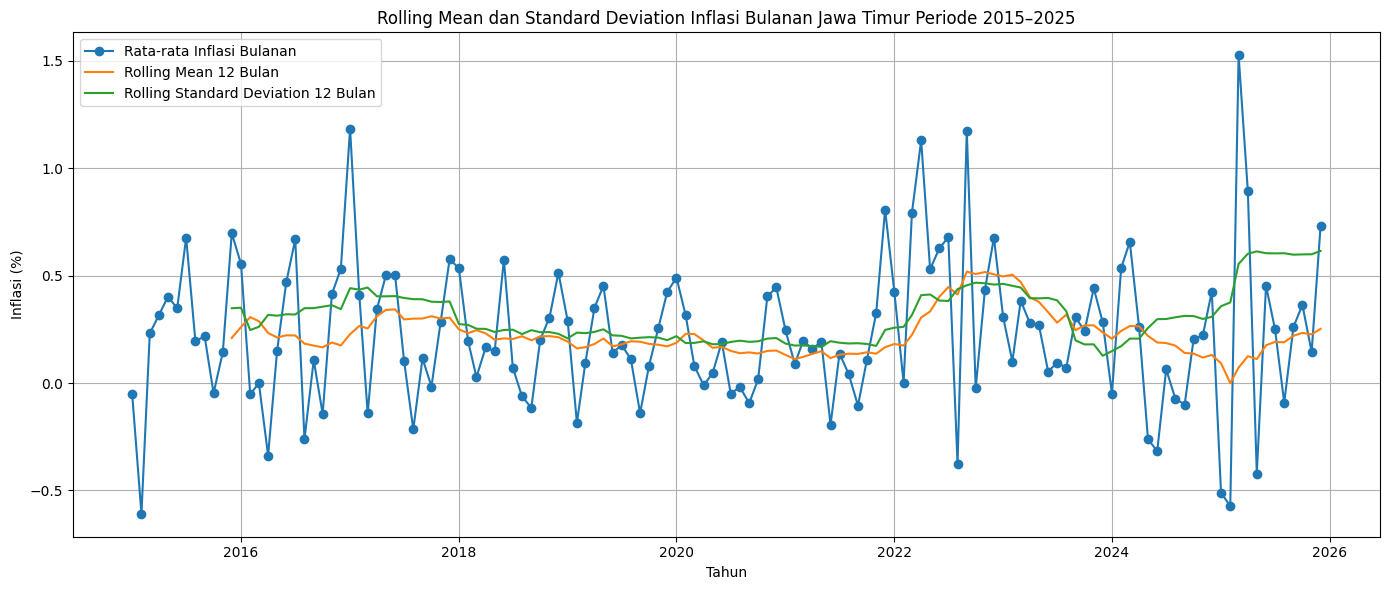

In [6]:
rolling_mean = df_jatim["inflasi"].rolling(window=12).mean()
rolling_std = df_jatim["inflasi"].rolling(window=12).std()

plt.figure(figsize=(14, 6))

plt.plot(df_jatim.index, df_jatim["inflasi"], marker="o", label="Rata-rata Inflasi Bulanan")
plt.plot(rolling_mean.index, rolling_mean, label="Rolling Mean 12 Bulan")
plt.plot(rolling_std.index, rolling_std, label="Rolling Standard Deviation 12 Bulan")

plt.title("Rolling Mean dan Standard Deviation Inflasi Bulanan Jawa Timur Periode 2015–2025")
plt.xlabel("Tahun")
plt.ylabel("Inflasi (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

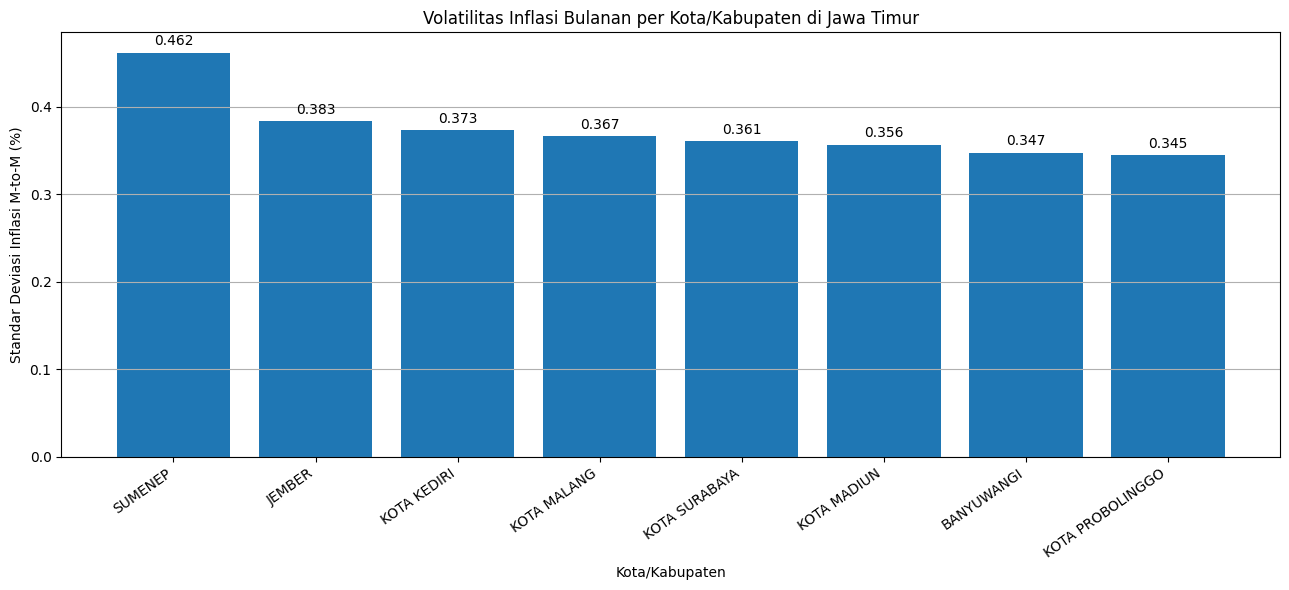

In [ ]:
volatilitas_kota = df_jatim_raw.groupby("KOTA")["Inflasi"].std().sort_values(ascending=False)

plt.figure(figsize=(13, 6))

plt.bar(volatilitas_kota.index, volatilitas_kota.values)

plt.title("Volatilitas Inflasi Bulanan per Kota/Kabupaten di Jawa Timur")
plt.xlabel("Kota/Kabupaten")
plt.ylabel("Standar Deviasi Inflasi (%)")

plt.xticks(rotation=35, ha="right")
plt.grid(True, axis="y")

for i, value in enumerate(volatilitas_kota.values):
    plt.text(
        i,
        value + 0.005,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

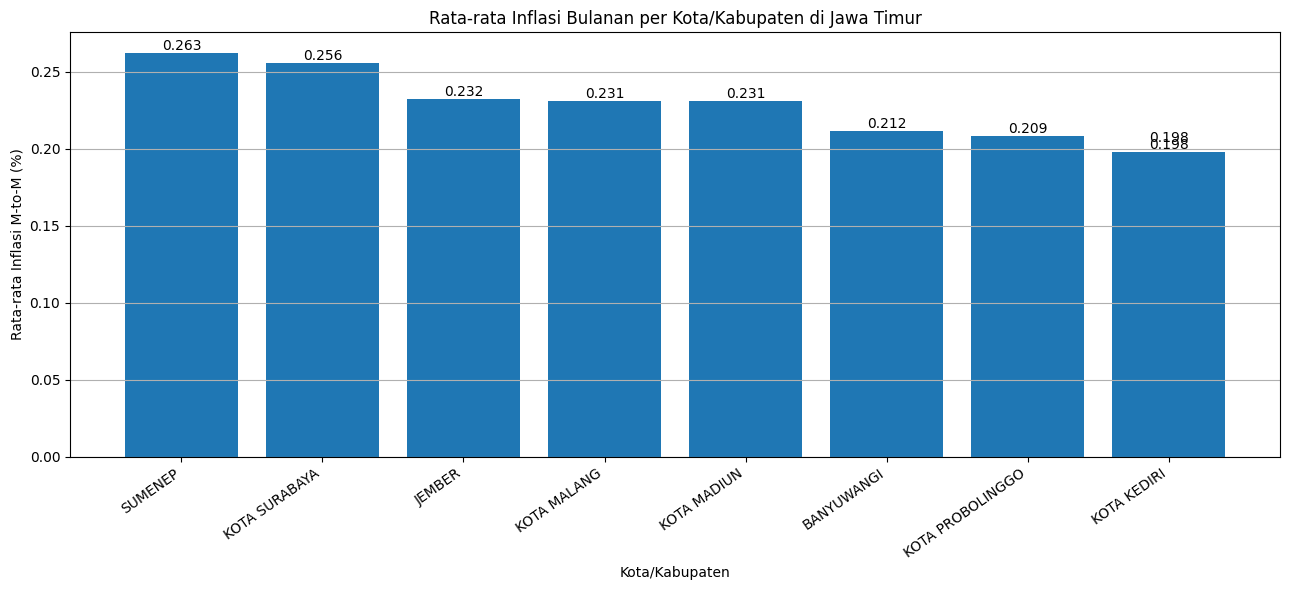

In [ ]:
rata_kota = df_jatim_raw.groupby("KOTA")["Inflasi"].mean().sort_values(ascending=False)

plt.figure(figsize=(13, 6))
plt.bar(rata_kota.index, rata_kota.values)

plt.title("Rata-rata Inflasi Bulanan per Kota/Kabupaten di Jawa Timur")
plt.xlabel("Kota/Kabupaten")
plt.ylabel("Rata-rata Inflasi (%)")
plt.xticks(rotation=35, ha="right")
plt.grid(True, axis="y")

for i, value in enumerate(rata_kota.values):
    plt.text(
        i,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Heatmap

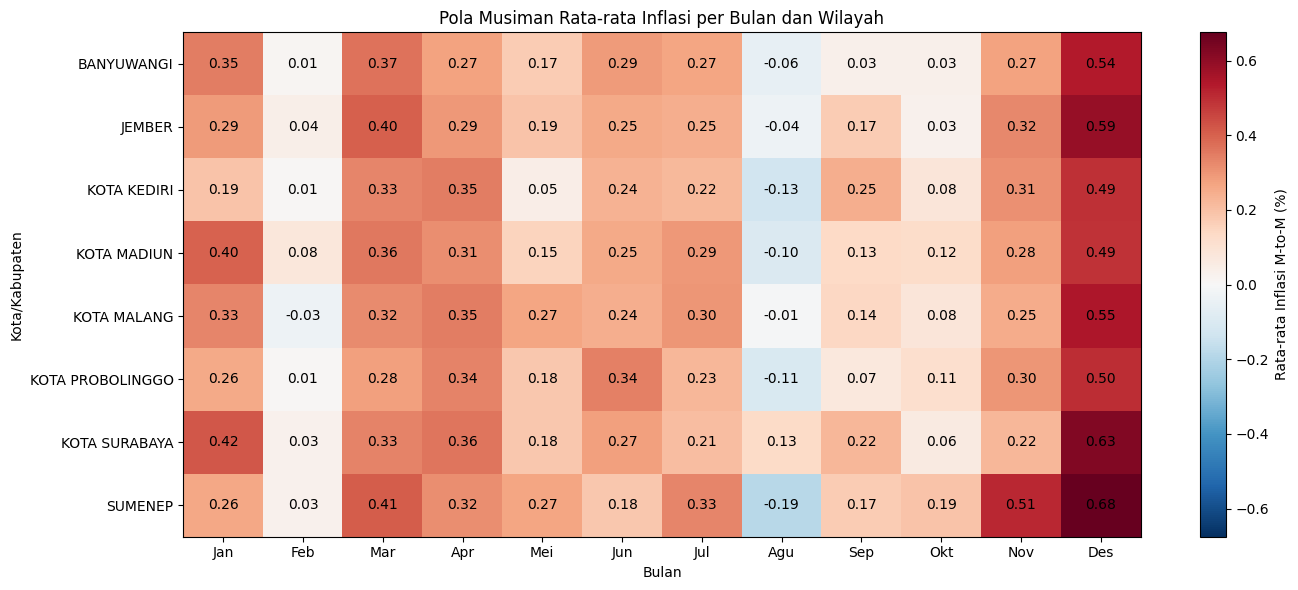

In [ ]:
df_jatim_raw["Bulan"] = df_jatim_raw["Tanggal"].dt.month

heatmap_data = (
    df_jatim_raw
    .groupby(["KOTA", "Bulan"])["Inflasi"]
    .mean()
    .unstack()
)

heatmap_data = heatmap_data.reindex(columns=range(1, 13))
heatmap_data = heatmap_data.rename(columns=bulan_map)

max_abs = np.nanmax(np.abs(heatmap_data.values))

plt.figure(figsize=(14, 6))

plt.imshow(
    heatmap_data,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-max_abs,
    vmax=max_abs
)

plt.xticks(np.arange(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(np.arange(len(heatmap_data.index)), heatmap_data.index)

plt.colorbar(label="Rata-rata Inflasi (%)")

plt.title("Pola Musiman Rata-rata Inflasi per Bulan dan Wilayah")
plt.xlabel("Bulan")
plt.ylabel("Kota/Kabupaten")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.tight_layout()
plt.show()

# Boxplot

C:\Users\firma\AppData\Local\Temp\ipykernel_3932\1249472789.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


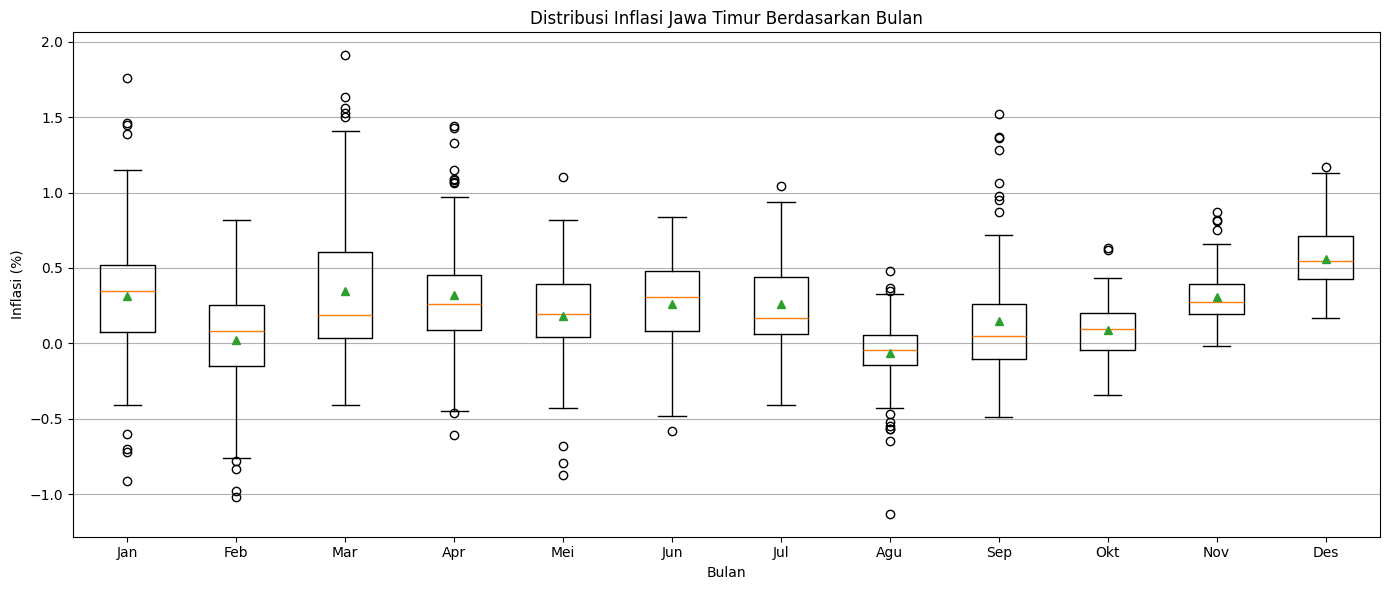

In [24]:
df_jatim_raw["Bulan"] = df_jatim_raw["Tanggal"].dt.month

data_boxplot = [
    df_jatim_raw[df_jatim_raw["Bulan"] == bulan]["Inflasi"].dropna()
    for bulan in range(1, 13)
]

plt.figure(figsize=(14, 6))

plt.boxplot(
    data_boxplot,
    labels=[bulan_map[i] for i in range(1, 13)],
    showmeans=True
)

plt.title("Distribusi Inflasi Jawa Timur Berdasarkan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Inflasi (%)")
plt.grid(True, axis="y")

plt.tight_layout()
plt.show()